# Gold and US treasury yields

## Research question

How has the relationship between gold and bond yields changed over time?

## Hypothesis
Increased treasury yields should put downward pressure on gold because of the opportunity cost of holding gold which is non-yielding


0.0005003297813043206
(775, 1) (775, 1)
[[-0.00378]] [0.72848022]


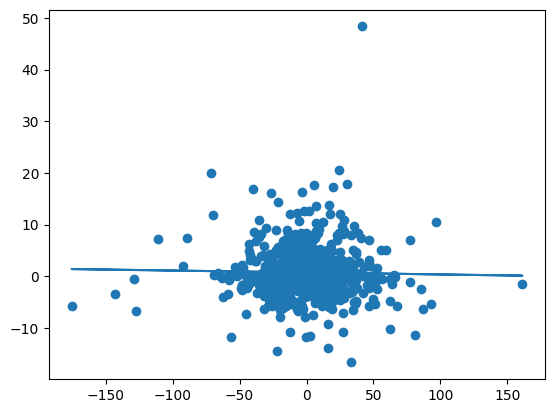

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

yields = pd.read_csv('../data/daily-yields.csv')
gold = pd.read_csv('../data/monthly-gold.csv')

yields = yields.rename(columns = {'observation_date':'Date'})
yields['Date'] = pd.to_datetime(yields['Date'])
gold['Date'] = pd.to_datetime(gold['Date'])

yields['Y/M']= yields['Date'].dt.strftime('%Y.%m')
gold['Y/M'] = gold['Date'].dt.strftime('%Y.%m')

yields = yields.groupby('Y/M')['DGS10'].mean()

comparison = pd.merge(yields, gold, on='Y/M')
comparison = comparison.rename(columns = {'Price':'Gold Price'})
comparison = comparison.rename(columns = {'DGS10':'US10Y yields'})

comparison['Gold Price (% Change)'] = comparison['Gold Price'].pct_change()*100
comparison['US10Y yields (bp Change)'] = comparison['US10Y yields'].diff()*100

plt.close('all')

gold_array = comparison['Gold Price (% Change)'].to_frame().dropna()
yields_array = comparison['US10Y yields (bp Change)'].to_frame().dropna()

model = LinearRegression()
model.fit(yields_array, gold_array)

plt.scatter(x= yields_array, y= gold_array)
plt.plot(yields_array, model.predict(yields_array))


print(r2_score(gold_array, model.predict(yields_array)))
print(gold_array.shape, yields_array.shape)
print(model.coef_, model.intercept_)